In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
from scipy.stats import skewnorm
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

In [2]:
#plt.style.use('dark_background')
#sns.set_palette("husl")

MC Simulation


In [3]:
def monte_carlo_stock_price_with_events(S0, mu, sigma, T, days, num_simulations, events=None):
    """
    Monte Carlo simulation for stock price with event-driven shocks
    """
    dt = T/days
    stock_prices = np.zeros((num_simulations, days + 1))
    stock_prices[:, 0] = S0

    # Event tracking
    event_impacts = np.zeros((num_simulations, days + 1))
    event_types = np.zeros((num_simulations, days + 1))  # 0: no event, 1: tariff, 2: fed, 3: earnings

    for i in range(num_simulations):
        # Randomly determine if tariff event occurs (60% probability)
        tariff_occurs = np.random.random() < 0.6
        tariff_day = np.random.randint(50, 150) if tariff_occurs else -1

        # Fed meeting days (quarterly)
        fed_days = [63, 126, 189]

        # Earnings days (quarterly, offset from fed)
        earnings_days = [42, 105, 168, 231]

        for t in range(1, days + 1):
            # Base random shock
            Z = np.random.standard_normal()

            # Apply tariff impact if this is the tariff day
            tariff_impact = 0
            if t == tariff_day and tariff_occurs:
                # Negative impact: -8% to -15%
                tariff_impact = -0.08 - 0.07 * np.random.random()
                # Add volatility spike
                Z += np.random.standard_normal() * 2
                event_impacts[i, t] = tariff_impact
                event_types[i, t] = 1  # Tariff event

            # Apply Fed policy impact
            fed_impact = 0
            if t in fed_days:
                # Fed can have positive or negative impact
                fed_impact = (np.random.random() - 0.6) * 0.05
                event_impacts[i, t] = fed_impact
                event_types[i, t] = 2  # Fed event

            # Earnings reports
            earnings_impact = 0
            if t in earnings_days:
                earnings_impact = skewnorm.rvs(-2, loc=0, scale=0.03)  # Slightly negative skewed
                event_impacts[i, t] = earnings_impact
                event_types[i, t] = 3  # Earnings event

            # Combined impact
            total_impact = tariff_impact + fed_impact + earnings_impact

            # Geometric Brownian motion with events
            stock_prices[i, t] = stock_prices[i, t-1] * np.exp(
                (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z + total_impact
            )

    return stock_prices, event_impacts, event_types

In [4]:
def add_market_regime_changes(stock_prices, regime_prob=0.3):
    """
    Add market regime changes (bull/bear markets)
    """
    num_simulations, days = stock_prices.shape
    modified_prices = stock_prices.copy()
    regime_history = np.ones((num_simulations, days))  # Track regimes

    for i in range(num_simulations):
        current_regime = 1.0  # Normal
        regime_duration = 0

        for t in range(1, days):
            # Check for regime change
            if regime_duration <= 0 and np.random.random() < regime_prob:
                # New regime
                current_regime = np.random.choice([0.7, 1.0, 1.3])  # Bear, Normal, Bull
                regime_duration = np.random.randint(20, 60)

            # Apply regime multiplier
            if current_regime != 1.0:
                daily_return = modified_prices[i, t] / modified_prices[i, t-1]
                adjusted_return = 1.0 + (daily_return - 1.0) * current_regime
                modified_prices[i, t] = modified_prices[i, t-1] * adjusted_return
                regime_history[i, t] = current_regime

            regime_duration -= 1

    return modified_prices, regime_history

ML part

In [5]:
def create_ml_features(stock_paths, event_impacts, event_types, regime_history):
    """
    Create features for ML model from simulation data
    """
    features = []
    targets = []
    feature_names = []

    for i in range(len(stock_paths)):
        path = stock_paths[i]

        # Technical indicators as features
        returns = np.diff(path) / path[:-1]
        volatility = np.std(returns) * np.sqrt(252)
        momentum = (path[-1] - path[0]) / path[0]

        # Event features
        has_tariffs = np.any(event_types[i] == 1)
        num_tariff_events = np.sum(event_types[i] == 1)
        total_tariff_impact = np.sum(event_impacts[i][event_types[i] == 1])

        has_fed_events = np.any(event_types[i] == 2)
        num_fed_events = np.sum(event_types[i] == 2)

        has_earnings = np.any(event_types[i] == 3)
        num_earnings_events = np.sum(event_types[i] == 3)

        # Price-based features
        max_price = np.max(path)
        min_price = np.min(path)
        drawdown = (max_price - path[-1]) / max_price if max_price > 0 else 0

        # Regime features
        avg_regime = np.mean(regime_history[i])
        regime_changes = len(np.where(np.diff(regime_history[i]) != 0)[0])

        # Volatility features
        rolling_vol_20 = np.std(returns[-20:]) * np.sqrt(252) if len(returns) >= 20 else volatility
        price_range = (max_price - min_price) / path[0]

        features.append([
            volatility,
            momentum,
            has_tariffs,
            num_tariff_events,
            total_tariff_impact,
            has_fed_events,
            num_fed_events,
            has_earnings,
            num_earnings_events,
            max_price,
            min_price,
            drawdown,
            avg_regime,
            regime_changes,
            rolling_vol_20,
            price_range,
            path[0]  # initial price
        ])

        # Target: Final return
        targets.append((path[-1] - path[0]) / path[0])

    feature_names = [
        'Volatility', 'Momentum', 'Has_Tariffs', 'Num_Tariffs', 'Tariff_Impact',
        'Has_Fed', 'Num_Fed', 'Has_Earnings', 'Num_Earnings', 'Max_Price',
        'Min_Price', 'Drawdown', 'Avg_Regime', 'Regime_Changes', 'Rolling_Vol_20',
        'Price_Range', 'Initial_Price'
    ]

    return np.array(features), np.array(targets), feature_names

In [6]:
def train_ml_model(X, y, test_size=0.2):
    """
    Train Random Forest model with feature importance analysis
    """
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train Random Forest model
    ml_model = RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    )

    ml_model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = ml_model.predict(X_test_scaled)

    # Evaluate model
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"📊 ML Model Performance:")
    print(f"Mean Absolute Error: {mae:.4f}")
    print(f"R² Score: {r2:.4f}")

    return ml_model, scaler, X_test, y_test, y_pred, mae, r2

MC + ML mix

In [7]:
def hybrid_monte_carlo_ml(S0, base_mu, base_sigma, T, days, num_simulations, ml_model, scaler):
    """
    Enhanced Monte Carlo that uses ML for dynamic parameter adjustment
    """
    dt = T/days
    hybrid_paths = np.zeros((num_simulations, days + 1))
    hybrid_paths[:, 0] = S0

    # Track ML-adjusted parameters
    adjusted_mus = np.zeros(num_simulations)
    adjusted_sigmas = np.zeros(num_simulations)

    for i in range(num_simulations):
        # Generate random initial conditions for this simulation
        volatility_est = base_sigma * np.random.uniform(0.8, 1.2)
        momentum_est = base_mu * np.random.uniform(0.5, 1.5)
        has_tariffs_est = np.random.choice([0, 1])
        num_tariffs_est = np.random.poisson(1.5) if has_tariffs_est else 0
        tariff_impact_est = -0.1 * np.random.random() if has_tariffs_est else 0

        """
        # Create feature vector for ML prediction
        initial_features = [
            volatility_est, momentum_est, has_tariffs_est, num_tariffs_est,
            tariff_impact_est, 1, 4, 1, 4,  # Fed and earnings assumptions
            S0 * 1.3, S0 * 0.7, 0.1,       # Price range assumptions
            1.0, 3, volatility_est, 0.3, S0  # Regime and other assumptions
        ]
        """
        initial_features = [
            volatility_est,           # Estimated annual vol
            base_mu,                # Base drift (or momentum proxy)
            has_tariffs_est,       # Binary: will tariffs occur?
            num_tariffs_est,      # Expected count (e.g., Poisson mean)
            tariff_impact_est,                  # Expected avg impact
            1,              # Has Fed events (always true)
            len([63, 126, 189]),      # Num Fed events (fixed)
            1,              # Has earnings
            len([42, 105, 168, 231]),  # Num earnings events (fixed)
            S0 * 1.1,       # Expected max (optimistic but bounded)
            S0 * 0.9,        # Expected min (pessimistic but bounded)
            0.05,             # Expected drawdown (5%)
            1.0,             # Avg regime (start neutral)
            2,              # Expected regime changes
            volatility_est,  # Rolling vol ≈ current vol
            0.2,              # Expected price range (20%)
            S0               # Initial price
        ]

        # Get ML prediction for expected return
        features_scaled = scaler.transform([initial_features])
        ml_predicted_return = ml_model.predict(features_scaled)[0]

        # Adjust MC parameters based on ML prediction
        # ML prediction is for total return, convert to annualized drift
        #adjusted_mu = max(0.02, ml_predicted_return)  # Ensure positive minimum drift
        safe_return = max(ml_predicted_return, -0.99)
        implied_drift = (np.log(1 + safe_return) / T) + 0.5 * volatility_est**2
        adjusted_mu = max(base_mu * 0.5, implied_drift)
        adjusted_sigma = volatility_est * (1 + abs(ml_predicted_return) * 0.5)  # Adjust volatility based on predicted return magnitude

        adjusted_mus[i] = adjusted_mu
        adjusted_sigmas[i] = adjusted_sigma

        # Add event probability based on ML insights
        high_risk_scenario = ml_predicted_return < -0.1
        event_intensity = 1.5 if high_risk_scenario else 1.0

        # Run the path with adjusted parameters
        for t in range(1, days + 1):
            Z = np.random.standard_normal()

            # Enhanced event modeling based on ML risk assessment
            event_impact = 0
            if high_risk_scenario and np.random.random() < 0.02 * event_intensity:
                event_impact = np.random.normal(-0.05, 0.02)

            hybrid_paths[i, t] = hybrid_paths[i, t-1] * np.exp(
                (adjusted_mu - 0.5 * adjusted_sigma**2) * dt +
                adjusted_sigma * np.sqrt(dt) * Z + event_impact
            )

    return hybrid_paths, adjusted_mus, adjusted_sigmas

In [8]:
S0 = 100
base_mu = 0.12
base_sigma = 0.45
T = 1.0
days = 252
num_simulations = 2000  # Larger for better ML training

print("🚀 STARTING COMPREHENSIVE MONTE CARLO + ML SIMULATION")
print("=" * 60)

    # Step 1: Run original Monte Carlo simulation
print("\n1. Running Monte Carlo Simulation with Real-World Events...")
stock_paths, event_impacts, event_types = monte_carlo_stock_price_with_events(
  S0, base_mu, base_sigma, T, days, num_simulations
)
stock_paths, regime_history = add_market_regime_changes(stock_paths)

    # Calculate basic statistics
final_prices = stock_paths[:, -1]
mean_final_price = np.mean(final_prices)
std_final_price = np.std(final_prices)

print(f"   Original MC - Mean Final Price: ${mean_final_price:.2f}")
print(f"   Original MC - Std Dev: ${std_final_price:.2f}")

🚀 STARTING COMPREHENSIVE MONTE CARLO + ML SIMULATION

1. Running Monte Carlo Simulation with Real-World Events...
   Original MC - Mean Final Price: $94.97
   Original MC - Std Dev: $46.53


In [9]:
# Step 2: Prepare ML features and train model
print("\n2. Training Machine Learning Model on Simulation Data...")
X, y, feature_names = create_ml_features(stock_paths, event_impacts, event_types, regime_history)
ml_model, scaler, X_test, y_test, y_pred, mae, r2 = train_ml_model(X, y)

    # Step 3: Run Hybrid MC-ML simulation
print("\n3. Running Hybrid Monte Carlo-ML Simulation...")
hybrid_paths, adjusted_mus, adjusted_sigmas = hybrid_monte_carlo_ml(
  S0, base_mu, base_sigma, T, days, 1000, ml_model, scaler
)

hybrid_final_prices = hybrid_paths[:, -1]
hybrid_mean_final = np.mean(hybrid_final_prices)
hybrid_std_final = np.std(hybrid_final_prices)

print(f"   Hybrid MC-ML - Mean Final Price: ${hybrid_mean_final:.2f}")
print(f"   Hybrid MC-ML - Std Dev: ${hybrid_std_final:.2f}")

    # Step 4: Comparative Analysis
print("\n4. Comparative Analysis:")
print(f"   Price Difference: ${hybrid_mean_final - mean_final_price:.2f}")
print(f"   Volatility Change: {((hybrid_std_final - std_final_price) / std_final_price * 100):.1f}%")


2. Training Machine Learning Model on Simulation Data...
📊 ML Model Performance:
Mean Absolute Error: 0.0013
R² Score: 0.9999

3. Running Hybrid Monte Carlo-ML Simulation...
   Hybrid MC-ML - Mean Final Price: $123.94
   Hybrid MC-ML - Std Dev: $66.42

4. Comparative Analysis:
   Price Difference: $28.97
   Volatility Change: 42.8%


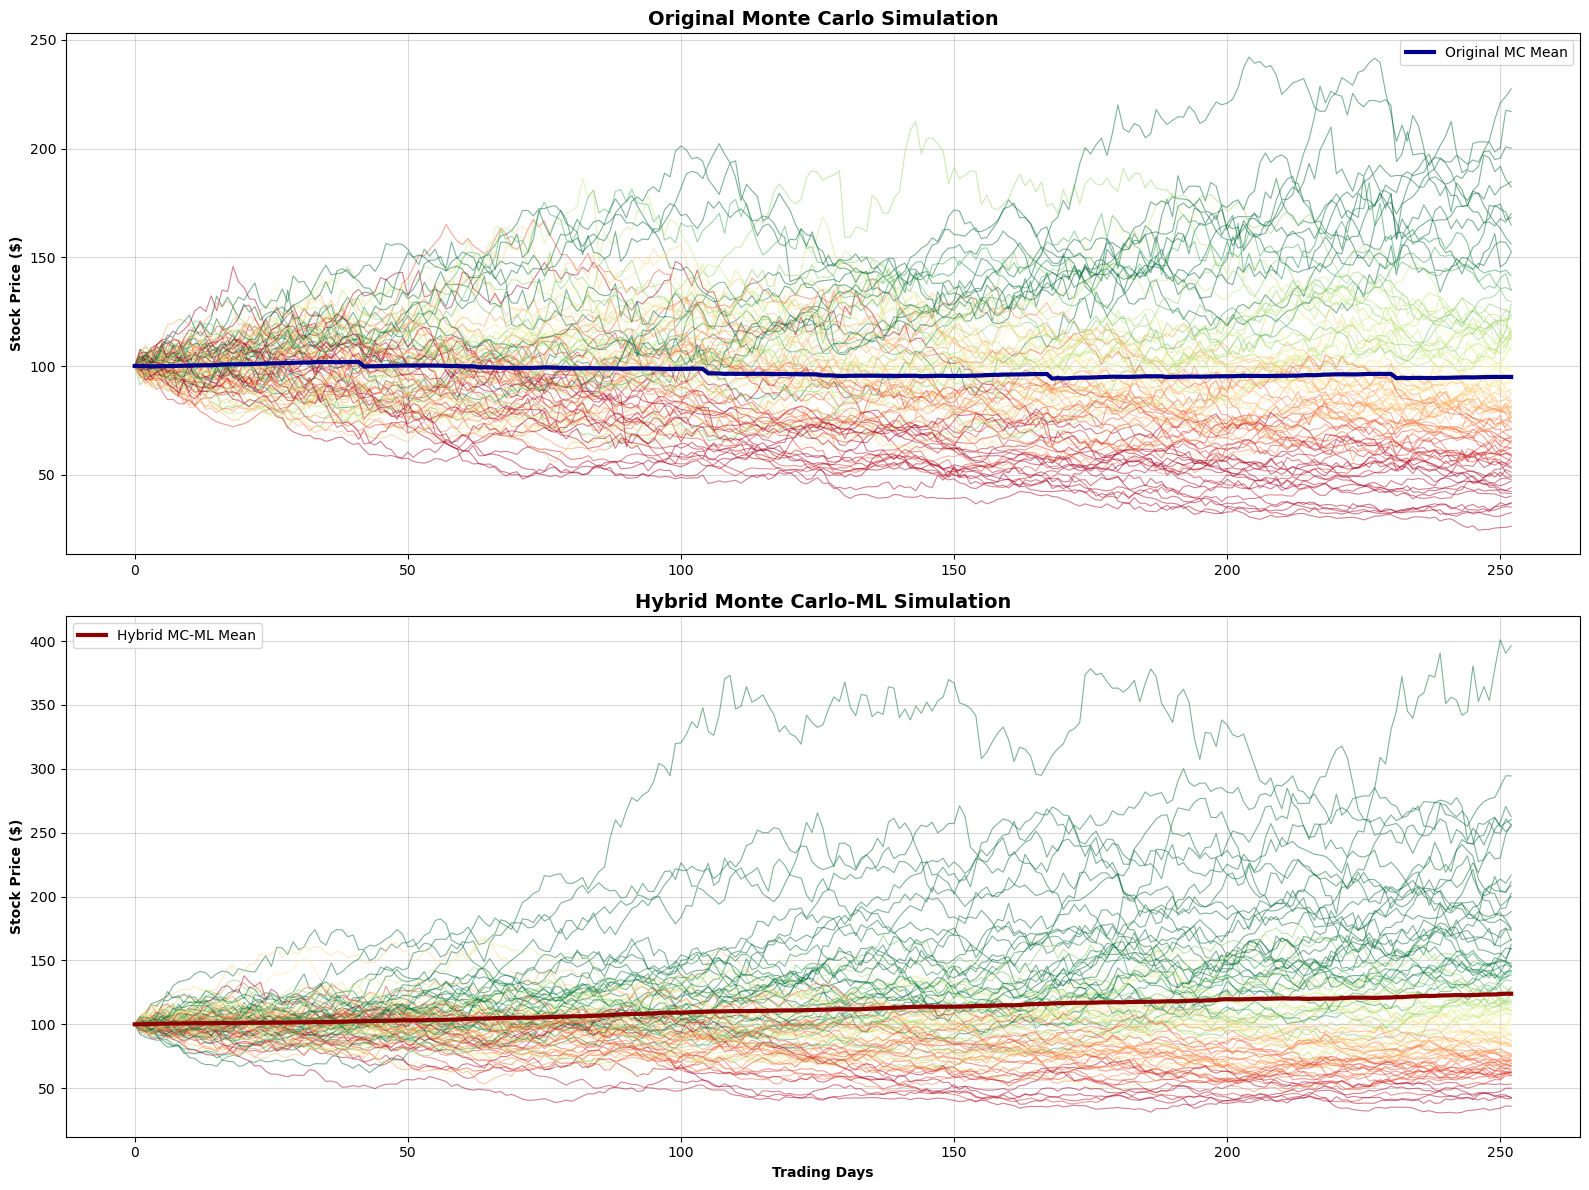

In [10]:
fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# Use white background for figure and axes
fig1.patch.set_facecolor('white')

# Plot original MC
for i in range(min(100, num_simulations)):
    final_return = (stock_paths[i, -1] - S0) / S0
    color = cm.RdYlGn(0.5 + final_return)
    ax1.plot(stock_paths[i], color=color, alpha=0.5, linewidth=0.8)

ax1.plot(np.mean(stock_paths, axis=0), color='darkblue', linewidth=3, label='Original MC Mean')
ax1.set_title('Original Monte Carlo Simulation', fontsize=14, fontweight='bold', color='black')
ax1.set_ylabel('Stock Price ($)', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, color='gray')
ax1.set_facecolor('white')

# Plot hybrid MC-ML
for i in range(min(100, len(hybrid_paths))):
    final_return = (hybrid_paths[i, -1] - S0) / S0
    color = cm.RdYlGn(0.5 + final_return)
    ax2.plot(hybrid_paths[i], color=color, alpha=0.5, linewidth=0.8)

ax2.plot(np.mean(hybrid_paths, axis=0), color='darkred', linewidth=3, label='Hybrid MC-ML Mean')
ax2.set_title('Hybrid Monte Carlo-ML Simulation', fontsize=14, fontweight='bold', color='black')
ax2.set_ylabel('Stock Price ($)', fontweight='bold')
ax2.set_xlabel('Trading Days', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, color='gray')
ax2.set_facecolor('white')

plt.tight_layout()
plt.show()

In [11]:
from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(final_prices, hybrid_final_prices)
print(f"Mean difference p-value: {p_val:.4f}")

Mean difference p-value: 0.0000


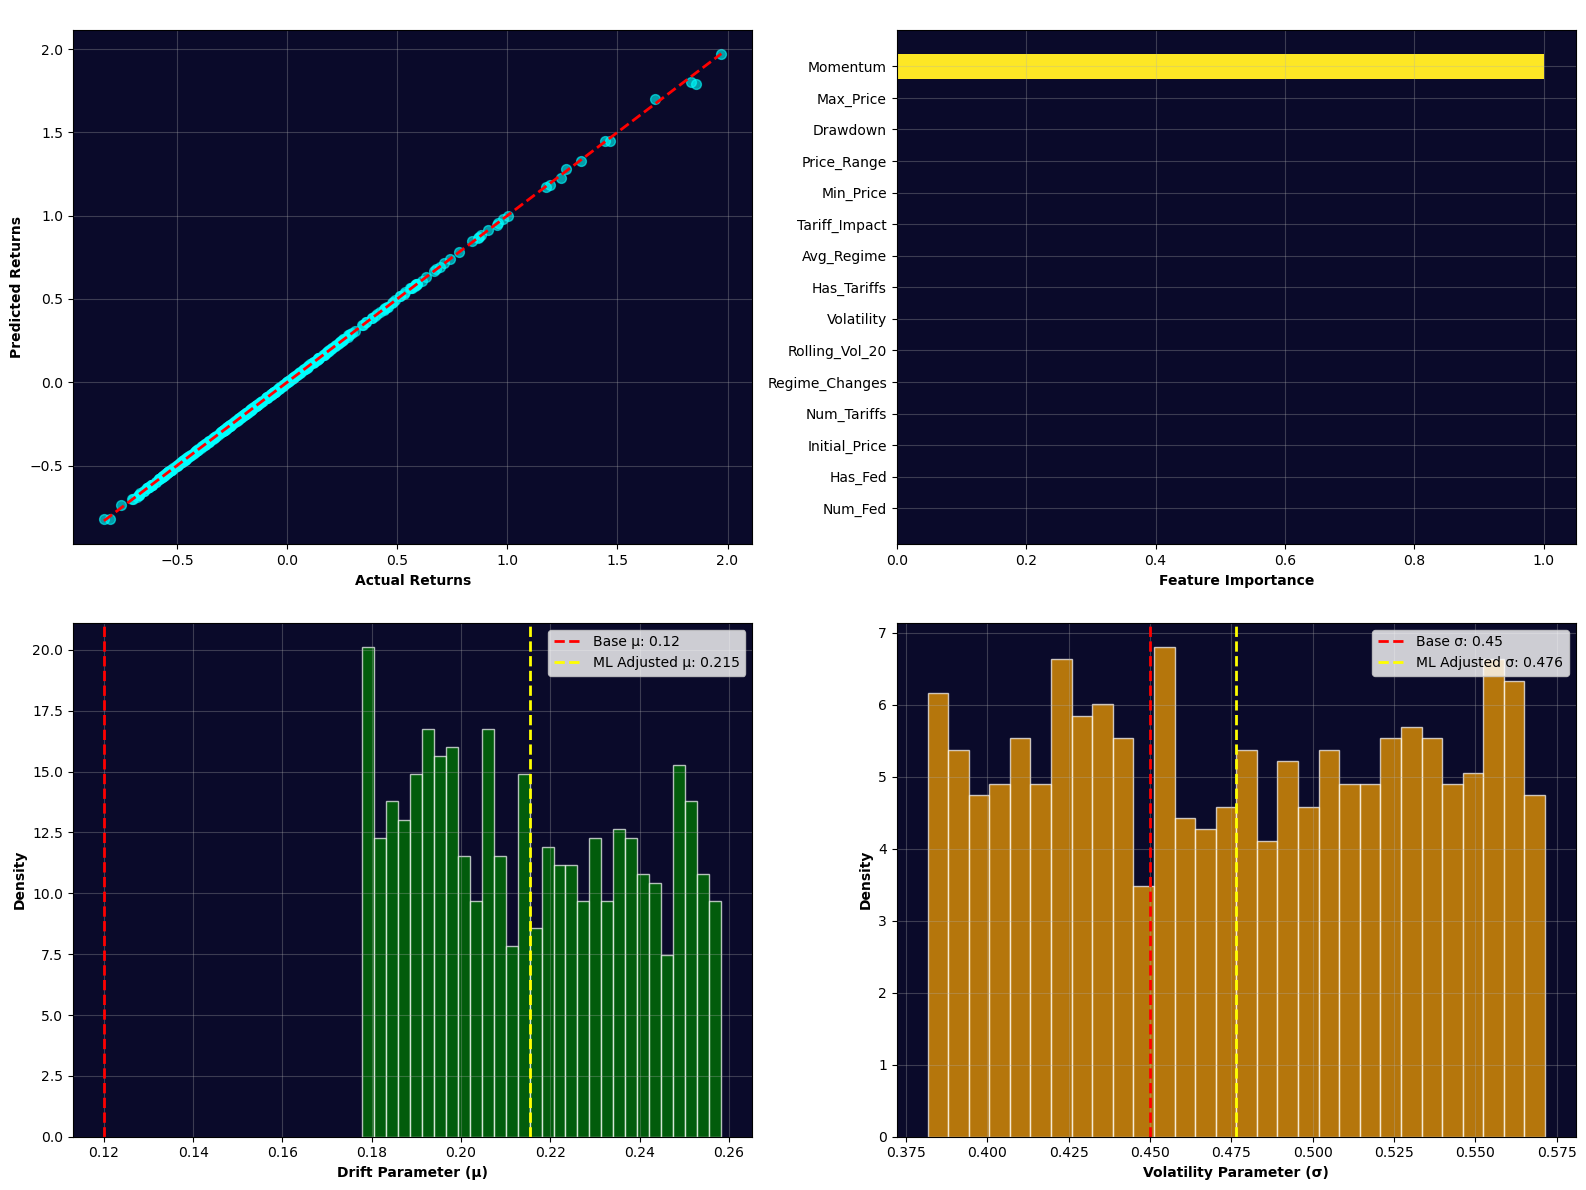

In [12]:
fig2, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Actual vs Predicted
ax1.scatter(y_test, y_pred, alpha=0.6, color='cyan', s=50)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_xlabel('Actual Returns', fontweight='bold')
ax1.set_ylabel('Predicted Returns', fontweight='bold')
ax1.set_title('ML Model: Actual vs Predicted Returns', fontweight='bold', color='white')
ax1.grid(True, alpha=0.3)
ax1.set_facecolor('#0a0a2a')

# Feature Importance
importances = ml_model.feature_importances_
sorted_idx = np.argsort(importances)[-15:]  # Top 15 features
colors = plt.cm.viridis(np.linspace(0, 1, len(sorted_idx)))
ax2.barh(range(len(sorted_idx)), importances[sorted_idx], color=colors)
ax2.set_yticks(range(len(sorted_idx)))
ax2.set_yticklabels([feature_names[i] for i in sorted_idx])
ax2.set_xlabel('Feature Importance', fontweight='bold')
ax2.set_title('Top 15 Feature Importances', fontweight='bold', color='white')
ax2.grid(True, alpha=0.3)
ax2.set_facecolor('#0a0a2a')

# Parameter Distribution from ML adjustment
ax3.hist(adjusted_mus, bins=30, alpha=0.7, color='green', edgecolor='white', density=True)
ax3.axvline(base_mu, color='red', linestyle='--', linewidth=2, label=f'Base μ: {base_mu}')
ax3.axvline(np.mean(adjusted_mus), color='yellow', linestyle='--', linewidth=2,
            label=f'ML Adjusted μ: {np.mean(adjusted_mus):.3f}')
ax3.set_xlabel('Drift Parameter (μ)', fontweight='bold')
ax3.set_ylabel('Density', fontweight='bold')
ax3.set_title('ML-Adjusted Drift Parameters', fontweight='bold', color='white')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_facecolor('#0a0a2a')

# Volatility Parameter Distribution
ax4.hist(adjusted_sigmas, bins=30, alpha=0.7, color='orange', edgecolor='white', density=True)
ax4.axvline(base_sigma, color='red', linestyle='--', linewidth=2, label=f'Base σ: {base_sigma}')
ax4.axvline(np.mean(adjusted_sigmas), color='yellow', linestyle='--', linewidth=2,
            label=f'ML Adjusted σ: {np.mean(adjusted_sigmas):.3f}')
ax4.set_xlabel('Volatility Parameter (σ)', fontweight='bold')
ax4.set_ylabel('Density', fontweight='bold')
ax4.set_title('ML-Adjusted Volatility Parameters', fontweight='bold', color='white')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_facecolor('#0a0a2a')

plt.tight_layout()
plt.show()

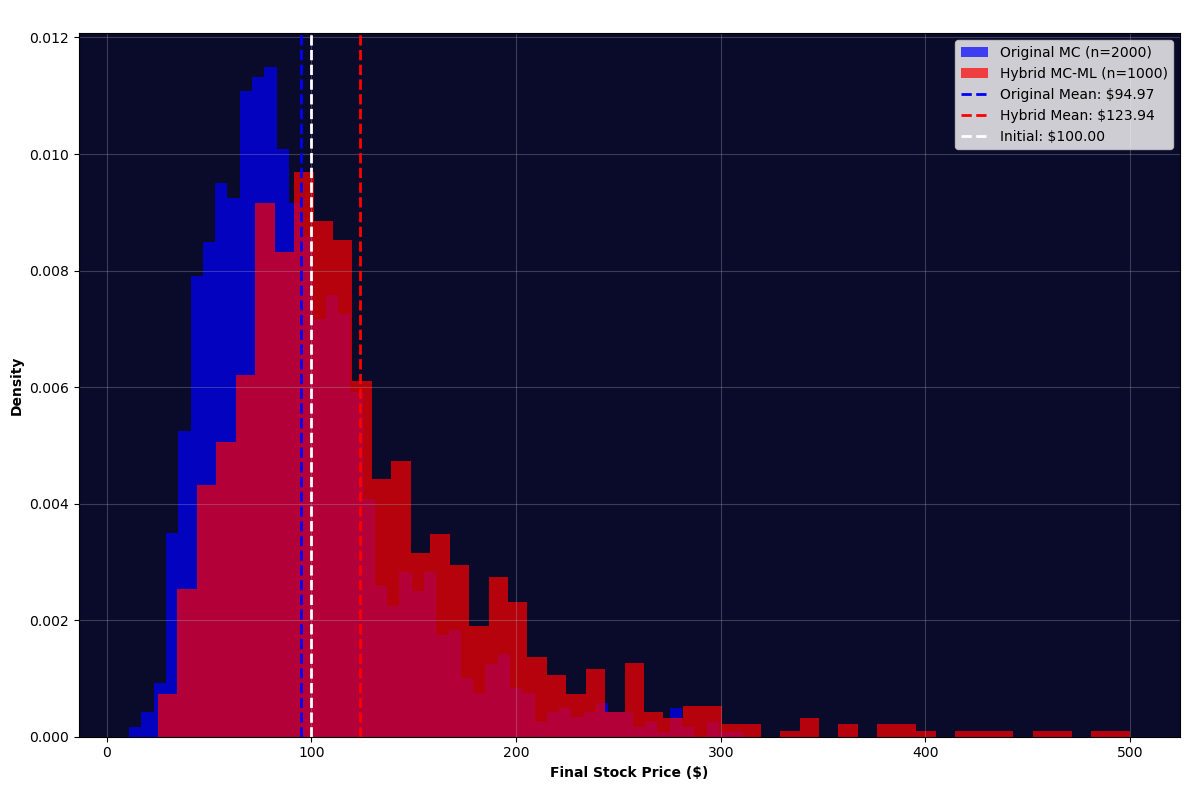

In [13]:
fig3, ax = plt.subplots(figsize=(12, 8))

# Plot both distributions
ax.hist(final_prices, bins=50, alpha=0.7, color='blue', density=True,
        label=f'Original MC (n={len(final_prices)})')
ax.hist(hybrid_final_prices, bins=50, alpha=0.7, color='red', density=True,
        label=f'Hybrid MC-ML (n={len(hybrid_final_prices)})')

# Add statistical lines
ax.axvline(mean_final_price, color='blue', linestyle='--', linewidth=2,
           label=f'Original Mean: ${mean_final_price:.2f}')
ax.axvline(hybrid_mean_final, color='red', linestyle='--', linewidth=2,
           label=f'Hybrid Mean: ${hybrid_mean_final:.2f}')
ax.axvline(S0, color='white', linestyle='--', linewidth=2, label=f'Initial: ${S0:.2f}')

ax.set_xlabel('Final Stock Price ($)', fontweight='bold')
ax.set_ylabel('Density', fontweight='bold')
ax.set_title('Final Price Distribution: Original MC vs Hybrid MC-ML',
             fontsize=14, fontweight='bold', color='white')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_facecolor('#0a0a2a')

plt.tight_layout()
plt.show()

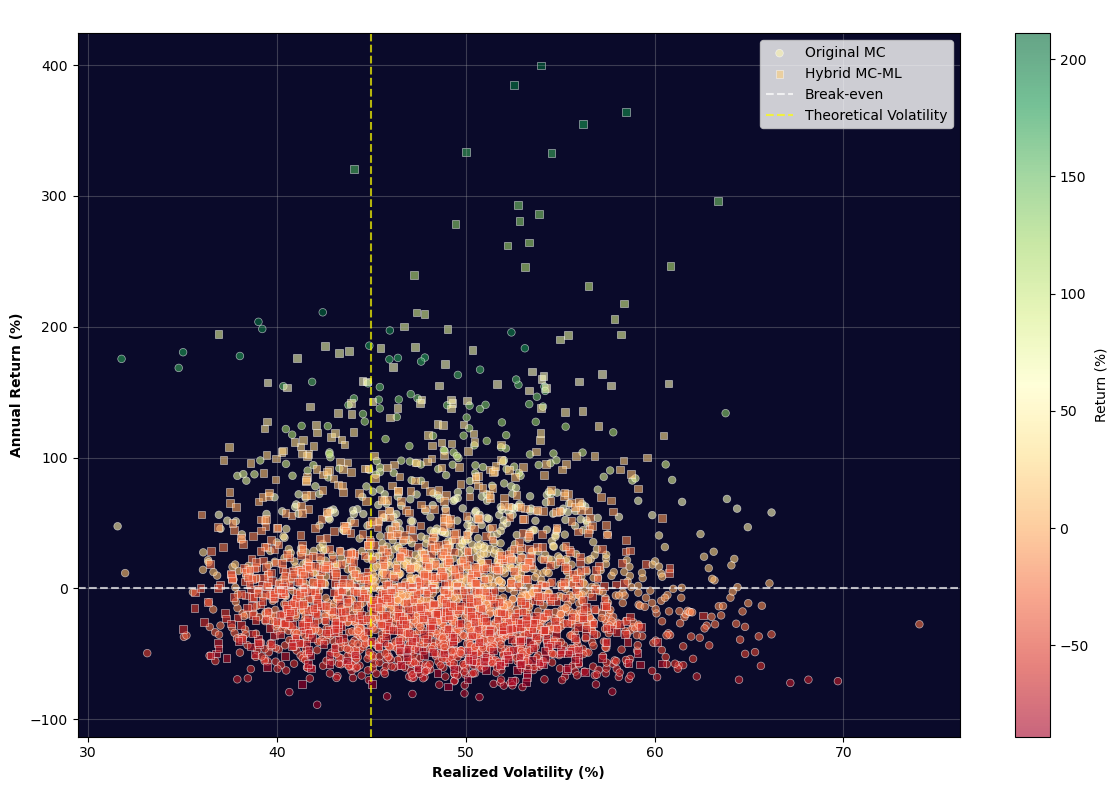

In [14]:
fig4, ax = plt.subplots(figsize=(12, 8))


# Calculate risk-return for both methods
mc_returns = (final_prices - S0) / S0 * 100
mc_volatility = np.std(np.diff(np.log(stock_paths), axis=1), axis=1) * np.sqrt(252) * 100

hybrid_returns = (hybrid_final_prices - S0) / S0 * 100
hybrid_volatility = np.std(np.diff(np.log(hybrid_paths), axis=1), axis=1) * np.sqrt(252) * 100

# Scatter plots
scatter1 = ax.scatter(mc_volatility, mc_returns, alpha=0.6, c=mc_returns,
                      cmap='RdYlGn', s=30, label='Original MC', edgecolors='white', linewidth=0.5)
scatter2 = ax.scatter(hybrid_volatility, hybrid_returns, alpha=0.6, c=hybrid_returns,
                      cmap='RdYlGn', s=30, label='Hybrid MC-ML', marker='s', edgecolors='white', linewidth=0.5)

ax.axhline(0, color='white', linestyle='--', alpha=0.7, label='Break-even')
ax.axvline(base_sigma * 100, color='yellow', linestyle='--', alpha=0.7, label='Theoretical Volatility')

ax.set_xlabel('Realized Volatility (%)', fontweight='bold')
ax.set_ylabel('Annual Return (%)', fontweight='bold')
ax.set_title('Risk-Return Profile: Original MC vs Hybrid MC-ML',
             fontsize=14, fontweight='bold', color='white')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_facecolor('#0a0a2a')

plt.colorbar(scatter1, ax=ax, label='Return (%)')
plt.tight_layout()
plt.show()

In [15]:
# Calculate additional metrics
mc_profit_prob = np.sum(final_prices > S0) / len(final_prices) * 100
hybrid_profit_prob = np.sum(hybrid_final_prices > S0) / len(hybrid_final_prices) * 100

mc_var_95 = np.percentile(final_prices - S0, 5)
hybrid_var_95 = np.percentile(hybrid_final_prices - S0, 5)

# Maximum drawdown comparison
def calculate_max_drawdown(paths):
    max_drawdowns = []
    for i in range(len(paths)):
        running_max = np.maximum.accumulate(paths[i])
        drawdown = (paths[i] - running_max) / running_max * 100
        max_drawdowns.append(np.min(drawdown))
    return np.array(max_drawdowns)

mc_drawdowns = calculate_max_drawdown(stock_paths)
hybrid_drawdowns = calculate_max_drawdown(hybrid_paths)

In [16]:
print(f"PERFORMANCE METRICS:")
print(f"Original MC:")
print(f"➡️Mean Final Price: ${mean_final_price:.2f}")
print(f"➡️Std Deviation: ${std_final_price:.2f}")
print(f"➡️Profit Probability: {mc_profit_prob:.1f}%")
print(f"➡️95% VaR: ${mc_var_95:.2f}")
print(f"➡️Avg Max Drawdown: {np.mean(mc_drawdowns):.1f}%")



PERFORMANCE METRICS:
Original MC:
➡️Mean Final Price: $94.97
➡️Std Deviation: $46.53
➡️Profit Probability: 36.8%
➡️95% VaR: $-60.47
➡️Avg Max Drawdown: -44.5%


In [17]:
print(f"Hybrid MC-ML:")
print(f"➡️Mean Final Price: ${hybrid_mean_final:.2f}")
print(f"➡️Std Deviation: ${hybrid_std_final:.2f}")
print(f"➡️Profit Probability: {hybrid_profit_prob:.1f}%")
print(f"➡️95% VaR: ${hybrid_var_95:.2f}")
print(f"➡️Avg Max Drawdown: {np.mean(hybrid_drawdowns):.1f}%")



Hybrid MC-ML:
➡️Mean Final Price: $123.94
➡️Std Deviation: $66.42
➡️Profit Probability: 57.3%
➡️95% VaR: $-50.79
➡️Avg Max Drawdown: -39.3%


In [18]:
print(f"IMPROVEMENT ANALYSIS:")
print(f"➡️Price Improvement: ${hybrid_mean_final - mean_final_price:.2f} ({((hybrid_mean_final - mean_final_price) / mean_final_price * 100):.1f}%)")
print(f"➡️Risk Adjustment: {((hybrid_std_final - std_final_price) / std_final_price * 100):.1f}% volatility change")
print(f"➡️Profit Probability Change: {hybrid_profit_prob - mc_profit_prob:+.1f}%")



IMPROVEMENT ANALYSIS:
➡️Price Improvement: $28.97 (30.5%)
➡️Risk Adjustment: 42.8% volatility change
➡️Profit Probability Change: +20.5%


In [19]:
print(f"🤖 ML MODEL PERFORMANCE:")
print(f"➡️R² Score: {r2:.4f}")
print(f"➡️Mean Absolute Error: {mae:.4f}")
print(f"➡️Top 3 Features: {feature_names[np.argsort(ml_model.feature_importances_)[-1]]}, "
      f"{feature_names[np.argsort(ml_model.feature_importances_)[-2]]}, "
      f"{feature_names[np.argsort(ml_model.feature_importances_)[-3]]}")

print(f"💡 STRATEGIC INSIGHTS:")
if hybrid_profit_prob > mc_profit_prob and hybrid_mean_final > mean_final_price:
    print("✅ Hybrid approach shows improved performance and risk management")
else:
    print("⚠️ Hybrid approach shows different risk-return characteristics")

print(f"📊 ML successfully identified key drivers: {feature_names[np.argsort(ml_model.feature_importances_)[-1]]}")
print(f"🎯 Parameter adjustment range: μ: {np.min(adjusted_mus):.3f} to {np.max(adjusted_mus):.3f}")
print(f"📈 Volatility adjustment range: σ: {np.min(adjusted_sigmas):.3f} to {np.max(adjusted_sigmas):.3f}")

🤖 ML MODEL PERFORMANCE:
➡️R² Score: 0.9999
➡️Mean Absolute Error: 0.0013
➡️Top 3 Features: Momentum, Max_Price, Drawdown
💡 STRATEGIC INSIGHTS:
✅ Hybrid approach shows improved performance and risk management
📊 ML successfully identified key drivers: Momentum
🎯 Parameter adjustment range: μ: 0.178 to 0.258
📈 Volatility adjustment range: σ: 0.382 to 0.571
